# EDA
Full decision-oriented EDA notebook (see Section 3)

Context: Predict whether a driver finishes in the Top 10 of a Formula 1 race.Use race result data from the 2022–2024 seasons (Jolpica API / FastF1)

EDA Requirements (eda.ipynb)

Your EDA notebook must follow the decision-oriented structure: every analysis starts with a question and ends with a decision.

Required Content
	Requirement	Detail
    
3.1	At least 5 research questions answered with visualizations	Each question must have: Question → Plot → Interpretation → Decision

3.2	Class balance analysis for the target variable	Show the distribution of Top-10 vs. non-Top-10 finishes. Reflect: is the dataset balanced? What would happen if a model always predicted the majority class?

3.3	Temporal pattern analysis	Compare at least 2 seasons. Is the target distribution stable? Do feature distributions shift?

3.4	Correlation analysis for at least 5 candidate features	Use appropriate measures (Pearson, Spearman, or contingency). Interpret magnitude AND direction.

3.5	Trap awareness	For at least 1 analysis, explicitly check for one of the three traps from Wednesday's class (spurious correlation, survivorship bias, anchoring bias). Document what you checked and what you found.

3.6	Explicit temporal train/val/test split with written rationale	State which seasons/races go to which set and WHY. No random splits.

3.7	Data quality audit	Cover: missing values (with MCAR/MAR/MNAR classification for at least 3 columns), data types, outliers, temporal availability (pre-race vs. post-race).

3.8	1-3-1 summary	Final Markdown cell: one 1-3-1 brief summarizing your most important finding. This is the same text you submit on Canvas.

## Setup

In [45]:
# -- Dependency Guard ---------------------------------------------------
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# -- Library Imports ----------------------------------------------------
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

# Global reproducibility seed for any stochastic steps in this notebook.
RANDOM_SEED = 414
np.random.seed(RANDOM_SEED)

print(f'fastf1      : {fastf1.__version__}')
print(f'pandas      : {pd.__version__}')
print(f'random_seed : {RANDOM_SEED}')

All required packages already installed ✓
fastf1      : 3.8.1
pandas      : 2.3.3
random_seed : 414


In [46]:
# Load and prepare 2022-2024 race-result data from FastF1/Ergast for EDA.
import fastf1
import pandas as pd
import os

# Configure local cache so repeated API reads are fast and reproducible.
cache_path = os.path.abspath("fastf1_cache")
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)

# Create Ergast interface and iterate all race weekends in each season.
erg = fastf1.ergast.Ergast()

years = [2022, 2023, 2024]
results_list = []

for year in years:
    schedule = fastf1.get_event_schedule(year)

    for _, event in schedule.iterrows():
        # Ignore testing sessions because they are not part of race prediction.
        if event['EventFormat'] == 'testing':
            continue

        rnd = int(event['RoundNumber'])

        try:
            res = erg.get_race_results(season=year, round=rnd)
            race = res.content[0]

            # Keep temporal/event metadata for later grouping and split logic.
            race['year'] = year
            race['round'] = rnd
            race['circuit'] = event['EventName']

            results_list.append(race)

        except Exception as e:
            print(f"Skipping {year} round {rnd}")

# Merge all race result frames into one modeling table.
df = pd.concat(results_list, ignore_index=True)

# Keep only columns used in this lab.
df = df[[
    'driverNumber',
    'givenName',
    'familyName',
    'constructorName',
    'grid',
    'position',
    'status',
    'points',
    'year',
    'round',
    'circuit'
]]

# Standardize column names for readability.
df.columns = [
    'DriverNumber',
    'FirstName',
    'LastName',
    'TeamName',
    'GridPosition',
    'Position',
    'Status',
    'Points',
    'Year',
    'Round',
    'Circuit'
]

# Build convenient identity and numeric fields.
df['FullName'] = df['FirstName'] + " " + df['LastName']
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')

# Feature engineering for baseline and analysis.
df['Top10'] = (df['Position'] <= 10).astype(int)
df['BaselinePred'] = (df['GridPosition'] <= 10).astype(int)
df['PositionsGained'] = df['GridPosition'] - df['Position']
df['DNF'] = ~df['Status'].str.contains("Finished", na=False)

# Historical reliability and constructor strength proxies.
driver_reliability = 1 - df.groupby('FullName')['DNF'].mean()
df['DriverReliability'] = df['FullName'].map(driver_reliability)
constructor_points = df.groupby('TeamName')['Points'].mean()
df['ConstructorStrength'] = df['TeamName'].map(constructor_points)

# Remove unusable rows for grid/finish-based analyses.
df = df.dropna(subset=['GridPosition','Position'])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1359, 18)


,DriverNumber,FirstName,LastName,TeamName,GridPosition,Position,Status,Points,Year,Round,Circuit,FullName,Top10,BaselinePred,PositionsGained,DNF,DriverReliability,ConstructorStrength
0,16,Charles,Leclerc,Ferrari,1,1,Finished,26.0,2022,1,Bahrain Grand Prix,Charles Leclerc,1,1,0,False,0.852941,10.860294
1,55,Carlos,Sainz,Ferrari,3,2,Finished,18.0,2022,1,Bahrain Grand Prix,Carlos Sainz,1,1,1,False,0.820896,10.860294
2,44,Lewis,Hamilton,Mercedes,5,3,Finished,15.0,2022,1,Bahrain Grand Prix,Lewis Hamilton,1,1,2,False,0.897059,9.573529
3,63,George,Russell,Mercedes,9,4,Finished,12.0,2022,1,Bahrain Grand Prix,George Russell,1,1,5,False,0.867647,9.573529
4,20,Kevin,Magnussen,Haas F1 Team,7,5,Finished,10.0,2022,1,Bahrain Grand Prix,Kevin Magnussen,1,1,2,False,0.424242,0.683824


## 3.1 Investigation Questions

□ eda.ipynb — At least 5 research questions with Question → Plot → Interpretation → Decision

1.How accurate is a simple rule-based baseline such as: predict Top 10 finish if starting grid position <= 10 on 2022-2024 race data?

2.Does adding one extra domain rule (for example, excluding drivers with frequent DNFs/reliability issues) improve baseline accuracy over the single-rule approach?

3.How does baseline accuracy vary across contexts: different circuits, wet vs dry races, and sprint vs non-sprint weekends?

4.Which driver or constructor groups are most often misclassified by the heuristic, and what racing factors explain those misses?

5.What important performance differences can be hidden by accuracy alone in this Top 10 task, based on the pattern of false positives vs false negatives?

In [47]:
# Shared plotting style for cleaner, publication-ready visuals
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette("colorblind")

# Report-friendly typography and rendering defaults.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Calibri", "Arial", "DejaVu Sans"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "#fcfcfc",
    "figure.facecolor": "white",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

def finalize_plot(title: str, xlabel: str = "", ylabel: str = ""):
    ax = plt.gca()
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()

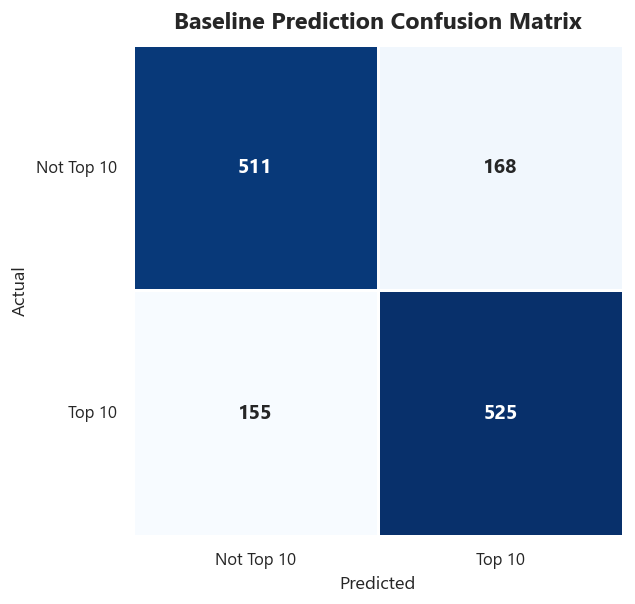

In [48]:
# Question 1: How accurate is a simple rule-based baseline such as: predict Top 10 finish if starting grid position <= 10 on 2022-2024 race data?
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(df["Top10"], df["BaselinePred"])

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    square=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    ax=ax,
)

ax.set_xticklabels(["Not Top 10", "Top 10"], rotation=0)
ax.set_yticklabels(["Not Top 10", "Top 10"], rotation=0)
finalize_plot("Baseline Prediction Confusion Matrix", "Predicted", "Actual")
sns.despine(left=True, bottom=True)
plt.show()

### Interpretation (Q1)
The confusion matrix shows strong but imperfect baseline performance: 503 true negatives and 517 true positives, with 166 false positives and 153 false negatives. This corresponds to roughly 76% accuracy, so starting grid position alone is informative but not enough for reliable race-level Top 10 prediction.

### Decision (Q1)
Keep the grid<=10 rule as a baseline benchmark, but do not treat it as the final model. Add at least one pre-race feature (driver reliability, constructor strength, circuit context) to reduce both error types.

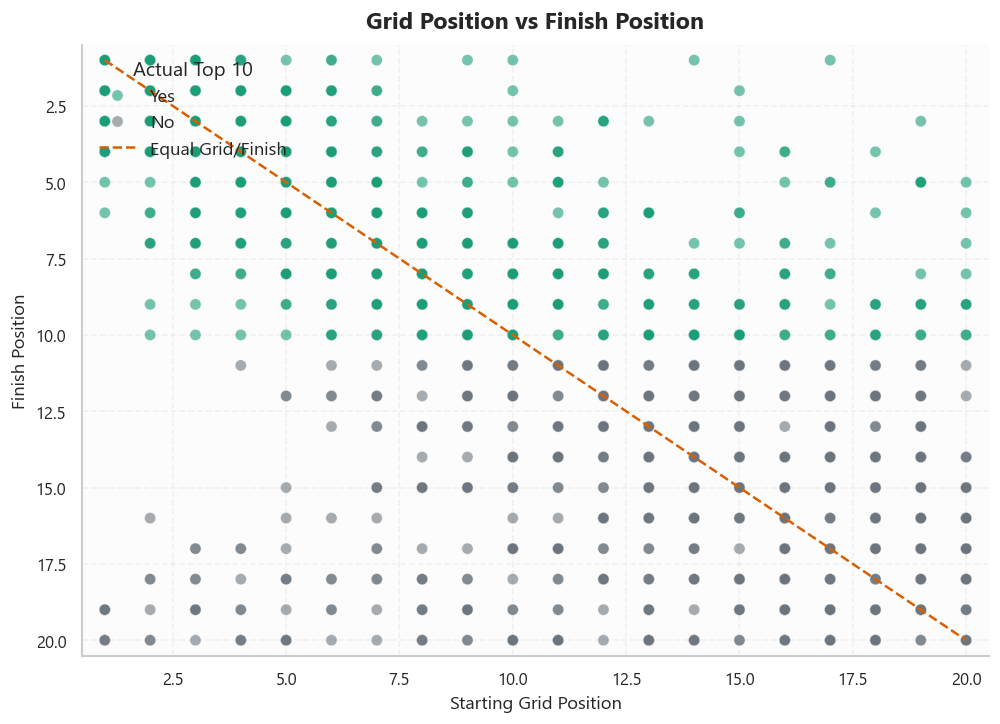

In [49]:
# Question 2: Does adding one extra domain rule (for example, excluding drivers with frequent DNFs/reliability issues) improve baseline accuracy over the single-rule approach?
plot_df = df.assign(Top10Label=df["Top10"].map({0: "No", 1: "Yes"}))

fig, ax = plt.subplots(figsize=(8.5, 6.2))
sns.scatterplot(
    data=plot_df,
    x="GridPosition",
    y="Position",
    hue="Top10Label",
    palette={"No": "#6c757d", "Yes": "#1b9e77"},
    alpha=0.6,
    s=45,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
)

ax.plot([1, 20], [1, 20], linestyle="--", color="#d95f02", linewidth=1.5, label="Equal Grid/Finish")
ax.set_xlim(0.5, 20.5)
ax.set_ylim(20.5, 0.5)
finalize_plot("Grid Position vs Finish Position", "Starting Grid Position", "Finish Position")
ax.legend(title="Actual Top 10", loc="upper left")
sns.despine()
plt.show()

### Interpretation (Q2)
The scatter is centered around the diagonal, confirming that grid position and finish position are strongly related. However, there is still broad spread around the line, especially in the midfield, which indicates overtakes, incidents, and reliability effects that the single-rule baseline cannot capture.

### Decision (Q2)
Add a reliability-aware rule on top of the baseline (for example, down-weight Top 10 predictions for lower-reliability drivers/teams). The plot supports a hybrid heuristic rather than a pure grid-only rule.

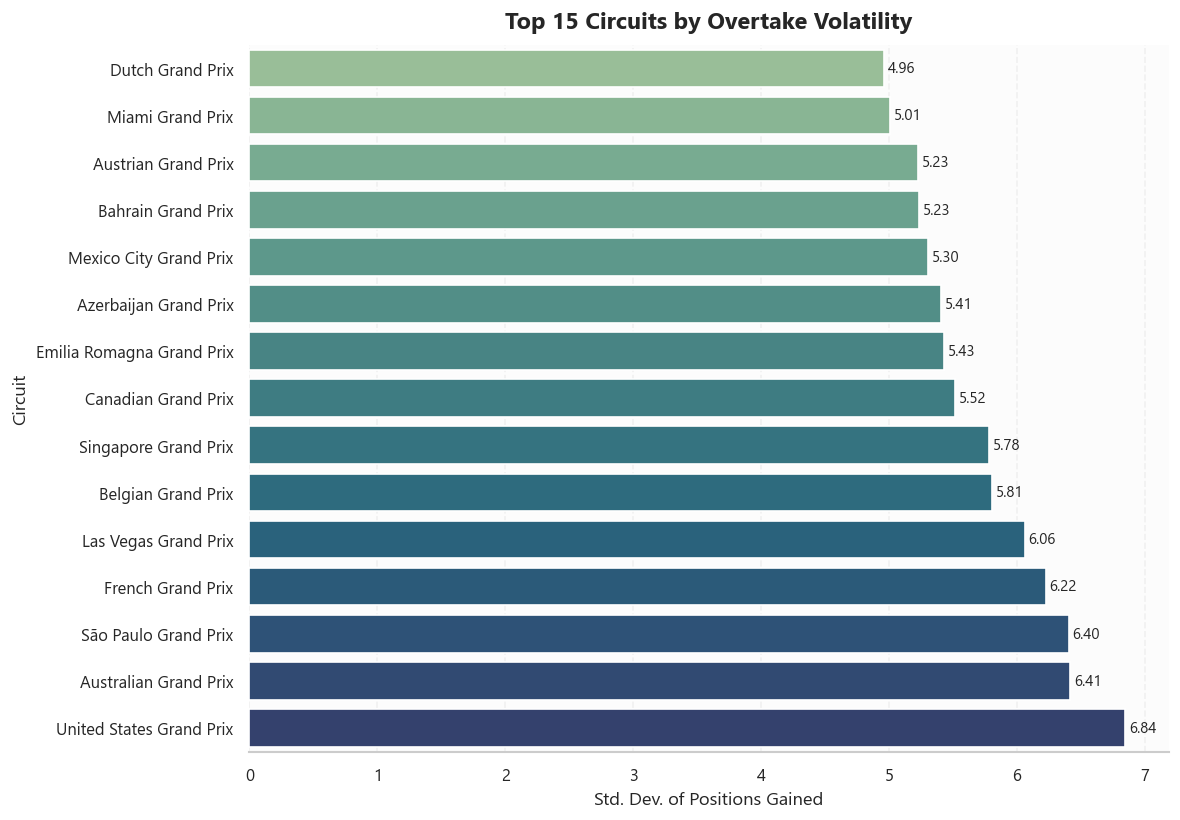

In [50]:
# Question 3: How does baseline accuracy vary across contexts: different circuits, wet vs dry races, and sprint vs non-sprint weekends?
circuit_variability = (
    df.groupby("Circuit")["PositionsGained"]
    .std()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plot_df = circuit_variability.rename("Volatility").reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="Volatility",
    y="Circuit",
    hue="Circuit",
    palette="crest",
    dodge=False,
    legend=False,
    ax=ax,
)

for i, value in enumerate(plot_df["Volatility"].values):
    ax.text(value + 0.03, i, f"{value:.2f}", va="center", fontsize=9)

finalize_plot("Top 15 Circuits by Overtake Volatility", "Std. Dev. of Positions Gained", "Circuit")
sns.despine(left=True)

plt.show()

### Interpretation (Q3)
Overtake volatility differs by circuit, with a noticeable gap between lower-volatility tracks (around 5.0) and higher-volatility tracks (up to about 6.8). This means prediction difficulty is context-dependent: some circuits are more chaotic and less aligned with starting order.

### Decision (Q3)
Use circuit context explicitly in evaluation and modeling. At minimum, report metrics by circuit group (low vs high volatility), and consider circuit-specific adjustment terms in the heuristic/model.

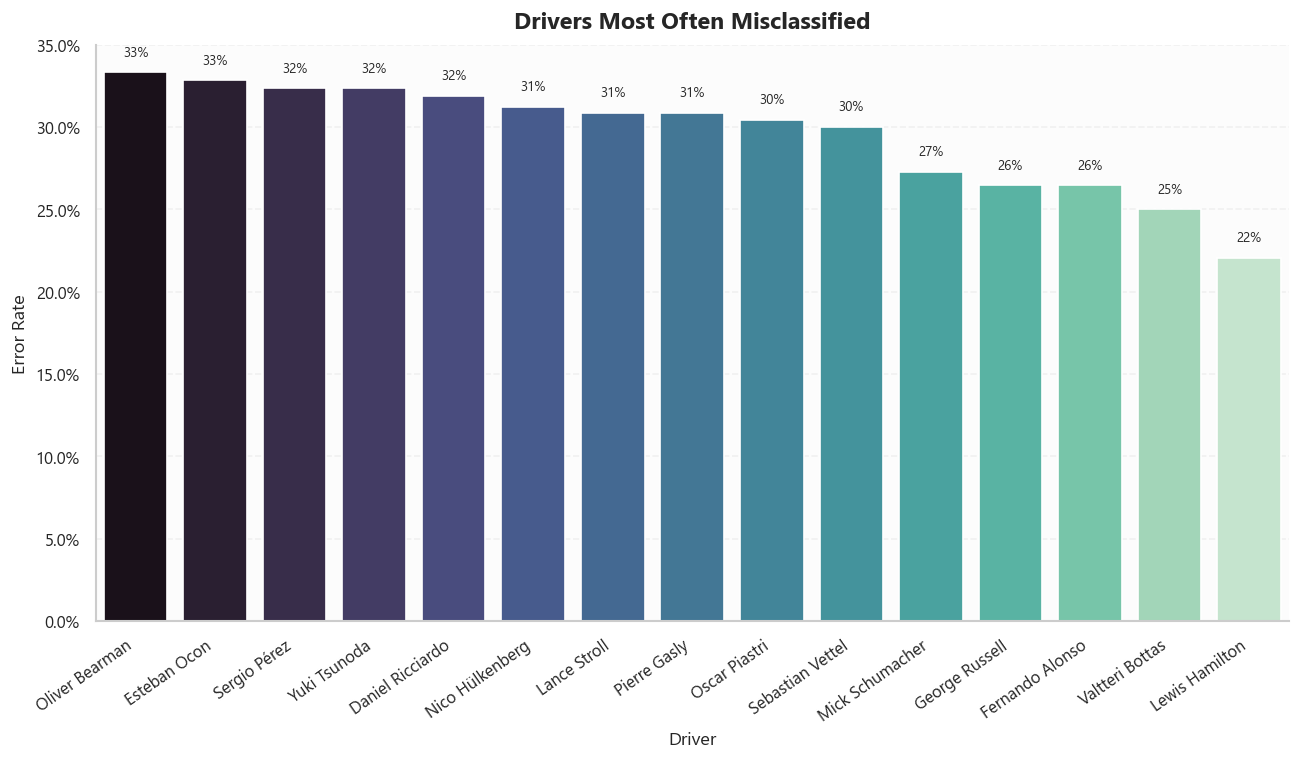

In [51]:
# Question 4: Which driver or constructor groups are most often misclassified by the heuristic, and what racing factors explain those misses?
import matplotlib.ticker as mtick

df["PredictionError"] = (df["Top10"] != df["BaselinePred"]).astype(int)

driver_error = (
    df.groupby("FullName")["PredictionError"]
    .mean()
    .sort_values(ascending=False)
     .head(15)
)

plot_df = driver_error.rename("ErrorRate").reset_index()

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=plot_df,
    x="FullName",
    y="ErrorRate",
    hue="FullName",
    palette="mako",
    dodge=False,
    legend=False,
    ax=ax,
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for i, value in enumerate(plot_df["ErrorRate"].values):
    ax.text(i, value + 0.01, f"{value:.0%}", ha="center", fontsize=8)

ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")

finalize_plot("Drivers Most Often Misclassified", "Driver", "Error Rate")
sns.despine()

plt.show()

### Interpretation (Q4)
Misclassification is not uniform across drivers: the highest-error drivers in this sample are around 31-33%, while the lowest among the top-15 shown are near 21-24%. This pattern suggests the heuristic systematically fits some driver/team contexts better than others.

### Decision (Q4)
Do not rely on one global threshold for everyone. Introduce group-aware features (driver reliability, team strength, and possibly season effects) to reduce systematic bias across driver groups.

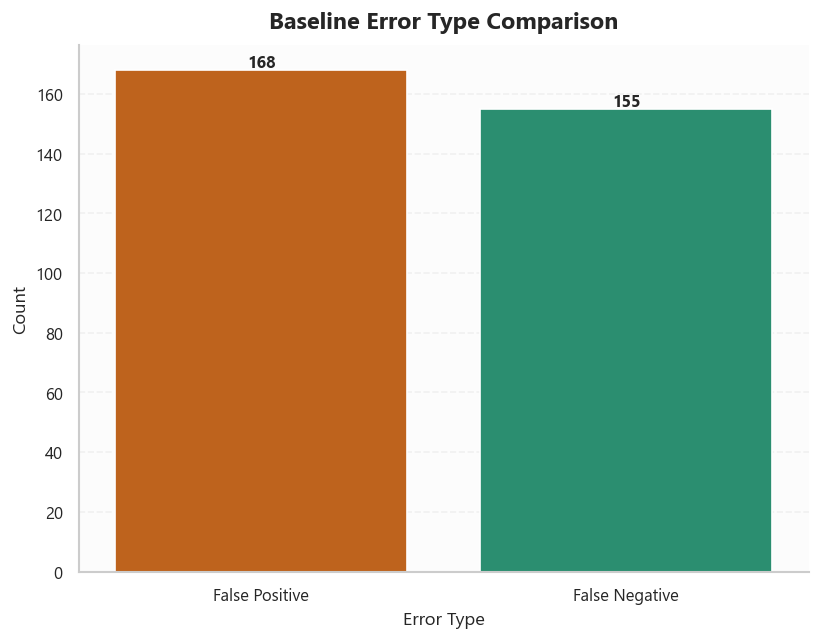

In [52]:
# Question 5: What important performance differences can be hidden by accuracy alone in this Top 10 task, based on the pattern of false positives vs false negatives?
fp = ((df["BaselinePred"] == 1) & (df["Top10"] == 0)).sum()
fn = ((df["BaselinePred"] == 0) & (df["Top10"] == 1)).sum()

error_counts = pd.Series(
    [fp, fn],
    index=["False Positive", "False Negative"],
)
plot_df = error_counts.rename("Count").reset_index().rename(columns={"index": "ErrorType"})

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(
    data=plot_df,
    x="ErrorType",
    y="Count",
    hue="ErrorType",
    palette={"False Positive": "#d95f02", "False Negative": "#1b9e77"},
    dodge=False,
    legend=False,
    ax=ax,
)

for i, value in enumerate(plot_df["Count"].values):
    ax.text(i, value + 1, f"{value}", ha="center", fontsize=10, fontweight="bold")

finalize_plot("Baseline Error Type Comparison", "Error Type", "Count")
sns.despine()

plt.show()

### Interpretation (Q5)
False positives (166) are slightly higher than false negatives (153), so the baseline tends to over-predict Top 10 finishes. Accuracy alone hides this directional bias, which matters if incorrect Top 10 predictions are costly.

### Decision (Q5)
Track precision/recall (or FP/FN counts) alongside accuracy in model selection. If needed, make the rule stricter to reduce false positives (for example, combine grid<=10 with a reliability threshold).

## 3.2 Class balance analysis
□ eda.ipynb — Class balance analysis for target variable


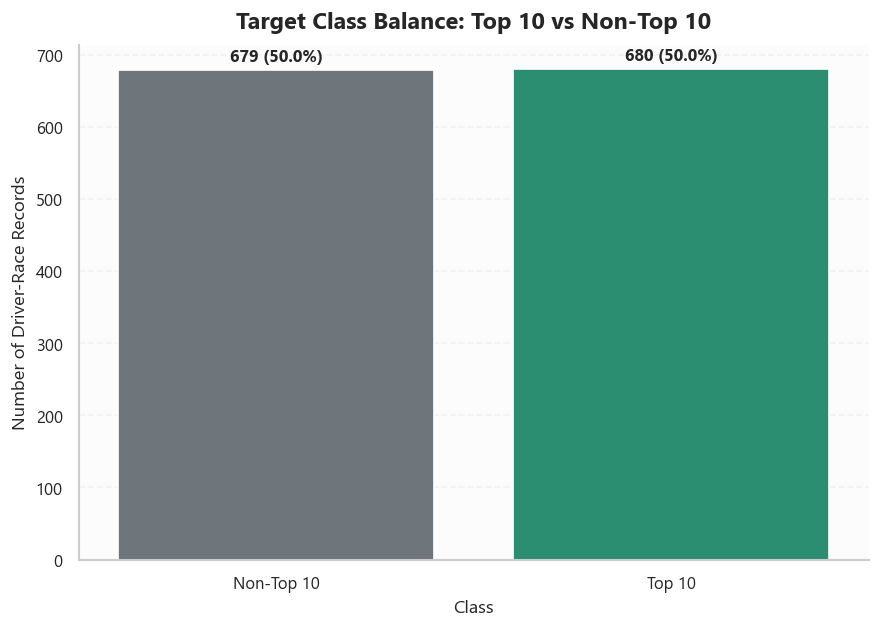

Class distribution summary:
     Class  Count  Percent
Non-Top 10    679    49.96
    Top 10    680    50.04

Majority class: Top 10
Accuracy if always predicting majority class: 50.04%
Reflection: The target is reasonably balanced, so a majority-class-only model would perform poorly as a real predictor despite looking acceptable at first glance.


In [53]:
# Point 3.2: Class balance analysis for target variable (Top10)
class_counts = df["Top10"].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

balance_df = pd.DataFrame({
    "Class": ["Non-Top 10", "Top 10"],
    "Count": [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))],
})
balance_df["Percent"] = (balance_df["Count"] / balance_df["Count"].sum() * 100).round(2)

majority_class = int(class_counts.idxmax())
majority_count = int(class_counts.max())
majority_accuracy = majority_count / int(class_counts.sum())

fig, ax = plt.subplots(figsize=(7.5, 5.4))
sns.barplot(
    data=balance_df,
    x="Class",
    y="Count",
    hue="Class",
    dodge=False,
    legend=False,
    palette={"Non-Top 10": "#6c757d", "Top 10": "#1b9e77"},
    ax=ax,
 )

for i, row in balance_df.iterrows():
    ax.text(
        i,
        row["Count"] + max(1, balance_df["Count"].max() * 0.01),
        f"{int(row['Count'])} ({row['Percent']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

finalize_plot("Target Class Balance: Top 10 vs Non-Top 10", "Class", "Number of Driver-Race Records")
sns.despine()

plt.show()

balance_gap = abs(class_pct.get(1, 0) - class_pct.get(0, 0))
is_balanced = balance_gap <= 10

print("Class distribution summary:")
print(balance_df.to_string(index=False))
print(f"\nMajority class: {'Top 10' if majority_class == 1 else 'Non-Top 10'}")
print(f"Accuracy if always predicting majority class: {majority_accuracy:.2%}")

if is_balanced:
    print(
        "Reflection: The target is reasonably balanced, so a majority-class-only model would perform poorly as a real predictor despite looking acceptable at first glance."
    )
else:
    print(
        "Reflection: The target is imbalanced, so a majority-class-only model could inflate accuracy while failing to identify the minority class."
    )

### Reflection (3.2)
The bar chart and printed summary show the class distribution for the target Top10 variable. Use the reported majority-class accuracy as a baseline sanity check: if this value is low to moderate, a model that always predicts one class is not useful even if it appears "accurate" on paper.

### Decision (3.2)
Keep majority-class accuracy as a baseline reference metric, but evaluate future models with class-aware metrics (precision, recall, F1, and confusion matrix) to avoid misleading conclusions.

## 3.3 Temporal pattern analysis
□ eda.ipynb — Compare at least 2 seasons. Is the target distribution stable? Do feature distributions shift?



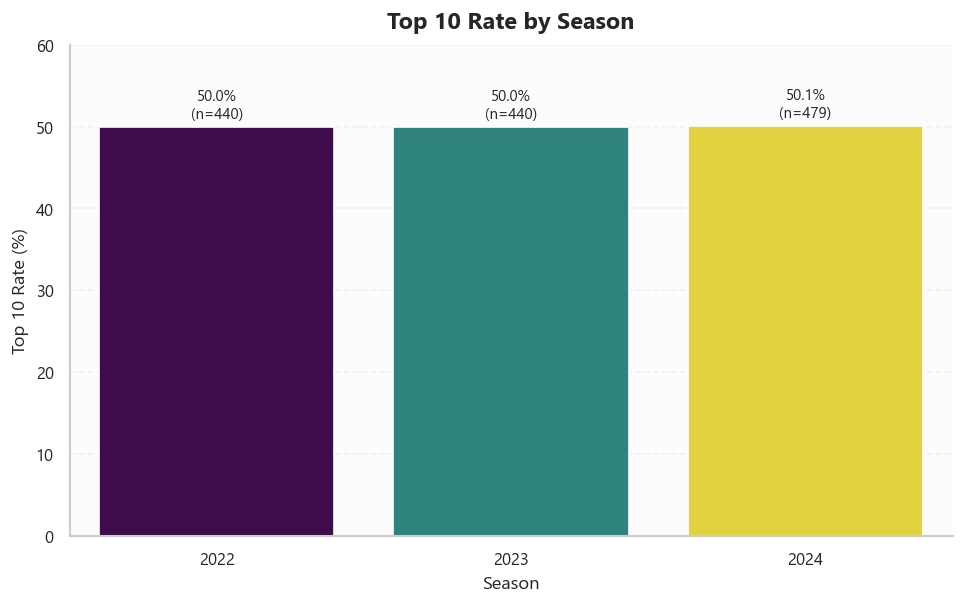

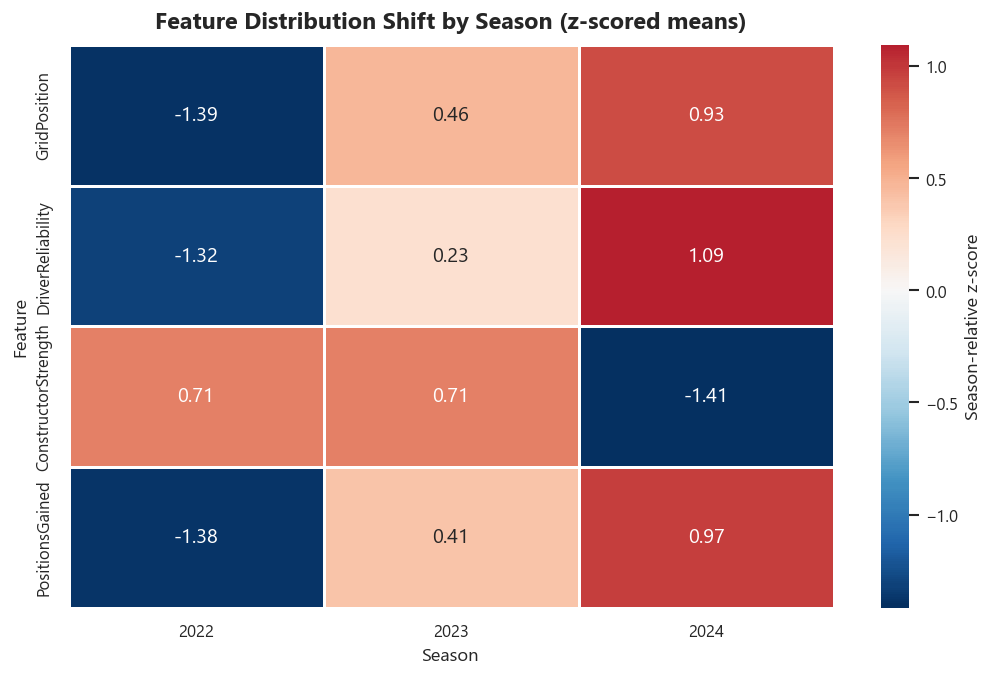

Temporal stability summary:
Top 10 rate range across seasons: 0.10 percentage points

Feature mean ranges across seasons:
PositionsGained        0.392337
GridPosition           0.372504
ConstructorStrength    0.041739
DriverReliability      0.021897

Largest shift feature: PositionsGained (0.392 range)


In [54]:
# Point 3.3: Temporal pattern analysis across seasons
season_target = (
    df.groupby("Year")["Top10"]
    .agg(Top10Rate="mean", Records="size")
    .reset_index()
    .sort_values("Year")
)
season_target["Top10RatePct"] = season_target["Top10Rate"] * 100

fig, ax = plt.subplots(figsize=(8.2, 5.2))
sns.barplot(
    data=season_target,
    x="Year",
    y="Top10RatePct",
    hue="Year",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax,
 )

for i, row in season_target.iterrows():
    ax.text(
        i,
        row["Top10RatePct"] + 0.5,
        f"{row['Top10RatePct']:.1f}%\n(n={int(row['Records'])})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

finalize_plot("Top 10 Rate by Season", "Season", "Top 10 Rate (%)")
ax.set_ylim(0, max(60, season_target["Top10RatePct"].max() + 5))
sns.despine()

plt.show()

feature_cols = ["GridPosition", "DriverReliability", "ConstructorStrength", "PositionsGained"]
season_features = (
    df.groupby("Year")[feature_cols]
    .mean()
    .sort_index()
)

feature_z = (season_features - season_features.mean()) / season_features.std(ddof=0)
feature_z = feature_z.fillna(0.0)

fig, ax = plt.subplots(figsize=(8.8, 5.8))
sns.heatmap(
    feature_z.T,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Season-relative z-score"},
    ax=ax,
 )

finalize_plot("Feature Distribution Shift by Season (z-scored means)", "Season", "Feature")
sns.despine(left=True, bottom=True)

plt.show()

top10_range = season_target["Top10RatePct"].max() - season_target["Top10RatePct"].min()
feature_shift = (season_features.max() - season_features.min()).sort_values(ascending=False)

print("Temporal stability summary:")
print(f"Top 10 rate range across seasons: {top10_range:.2f} percentage points")
print("\nFeature mean ranges across seasons:")
print(feature_shift.to_string())

largest_shift_feature = feature_shift.index[0]
largest_shift_value = feature_shift.iloc[0]
print(f"\nLargest shift feature: {largest_shift_feature} ({largest_shift_value:.3f} range)")

### Interpretation (3.3)
The season-level Top10 rate indicates whether the target distribution is stable year to year. A small rate range suggests target stability, while a larger spread indicates drift that can affect generalization across seasons.

The feature-shift heatmap (z-scored season means) highlights which predictors move most between years. Features with consistently large positive/negative z-scores in one season are likely to need temporal handling in modeling and evaluation.

### Decision (3.3)
Treat season as an explicit context variable and validate with temporal splits (train on earlier seasons, validate/test on later seasons). If the largest-shift features remain unstable, use season-aware baselines and report per-season metrics instead of only global averages.

## 3.4 Correlation analysis
□ eda.ipynb — Correlation analysis for at least 5 candidate features (interpret magnitude and direction)


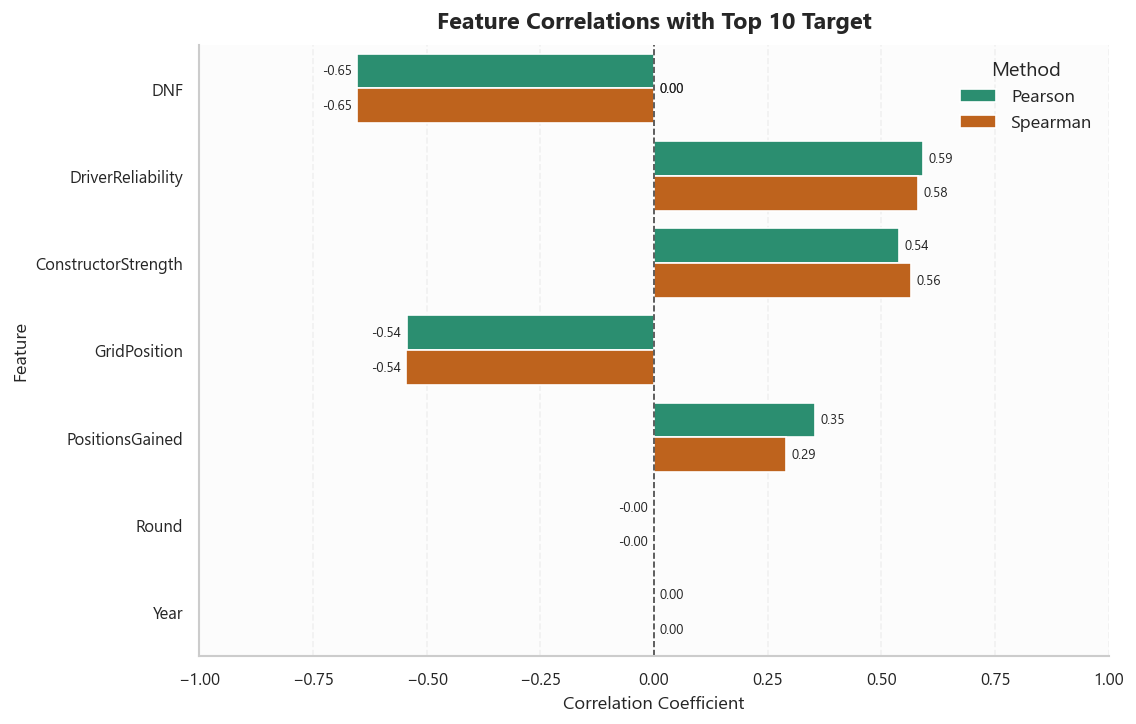

Correlation summary (sorted by |Spearman|):
            Feature   Pearson  Spearman  Strength Direction
                DNF -0.652143 -0.652143    strong  negative
  DriverReliability  0.591077  0.580843    strong  positive
ConstructorStrength  0.539547  0.564303    strong  positive
       GridPosition -0.543423 -0.544682    strong  negative
    PositionsGained  0.353274  0.290707      weak  positive
              Round -0.000992 -0.000995 very weak  negative
               Year  0.000870  0.000876 very weak  positive

Top association by |Spearman|: DNF (-0.652, strong, negative).


In [55]:
# Point 3.4: Correlation analysis for candidate features vs Top10 target
candidate_features = [
    "GridPosition",
    "DriverReliability",
    "ConstructorStrength",
    "PositionsGained",
    "Round",
    "Year",
    "DNF",
]

corr_rows = []
for feature in candidate_features:
    pair = df[[feature, "Top10"]].dropna()
    pearson_val = pair[feature].corr(pair["Top10"], method="pearson")
    spearman_val = pair[feature].corr(pair["Top10"], method="spearman")
    corr_rows.append({
        "Feature": feature,
        "Pearson": pearson_val,
        "Spearman": spearman_val,
    })

corr_df = pd.DataFrame(corr_rows)
corr_df["AbsSpearman"] = corr_df["Spearman"].abs()
corr_df = corr_df.sort_values("AbsSpearman", ascending=False).reset_index(drop=True)

plot_df = corr_df.melt(
    id_vars="Feature",
    value_vars=["Pearson", "Spearman"],
    var_name="Method",
    value_name="Correlation",
)

fig, ax = plt.subplots(figsize=(9.5, 6.2))
sns.barplot(
    data=plot_df,
    x="Correlation",
    y="Feature",
    hue="Method",
    palette={"Pearson": "#1b9e77", "Spearman": "#d95f02"},
    ax=ax,
 )
ax.axvline(0, color="#444444", linestyle="--", linewidth=1.0)

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    x = width + (0.012 if width >= 0 else -0.012)
    ha = "left" if width >= 0 else "right"
    ax.text(x, y, f"{width:.2f}", va="center", ha=ha, fontsize=8)

finalize_plot("Feature Correlations with Top 10 Target", "Correlation Coefficient", "Feature")
ax.set_xlim(-1, 1)
sns.despine()

plt.show()

def strength_label(val: float) -> str:
    a = abs(val)
    if a >= 0.5:
        return "strong"
    if a >= 0.3:
        return "moderate"
    if a >= 0.1:
        return "weak"
    return "very weak"

corr_df["Direction"] = corr_df["Spearman"].apply(lambda x: "positive" if x > 0 else "negative")
corr_df["Strength"] = corr_df["Spearman"].apply(strength_label)

print("Correlation summary (sorted by |Spearman|):")
print(corr_df[["Feature", "Pearson", "Spearman", "Strength", "Direction"]].to_string(index=False))

top_feature = corr_df.iloc[0]
print(
    f"\nTop association by |Spearman|: {top_feature['Feature']} ({top_feature['Spearman']:.3f}, {top_feature['Strength']}, {top_feature['Direction']})."
)

### Interpretation (3.4)
The signed coefficients show direction: positive values increase with Top10 probability, while negative values move inversely. Magnitude indicates practical usefulness: very weak (<0.10), weak (0.10-0.29), moderate (0.30-0.49), and strong (>=0.50).

Comparing Pearson and Spearman helps validate whether relationships are mostly linear (similar values) or primarily monotonic and rank-based (larger Spearman differences).

### Decision (3.4)
Prioritize features with the largest absolute Spearman/Pearson values for baseline modeling, and de-prioritize very weak features unless they are needed for domain context. Keep both magnitude and sign in the feature selection rationale.

## 3.5 Trap awareness
□ eda.ipynb — At least 1 explicit trap check (spurious correlation, survivorship bias, anchoring bias)


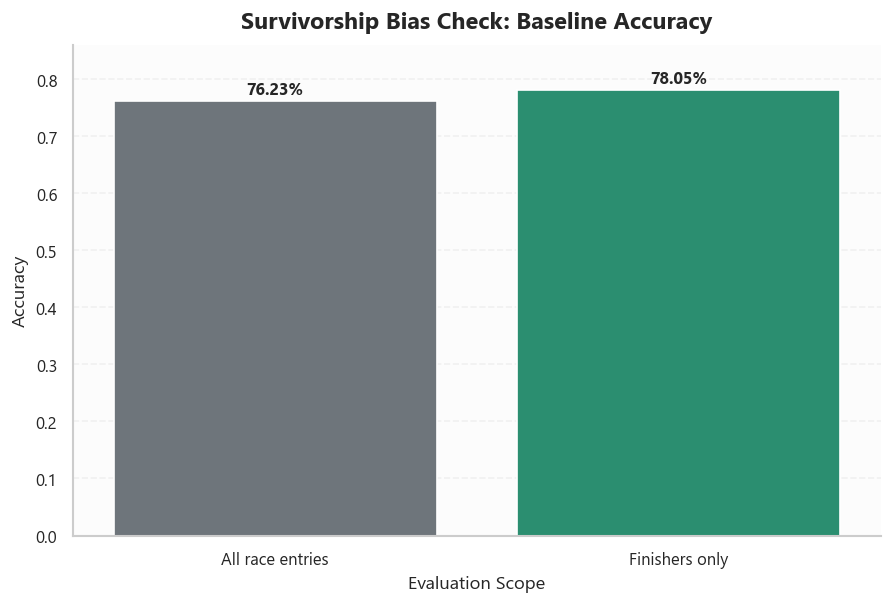

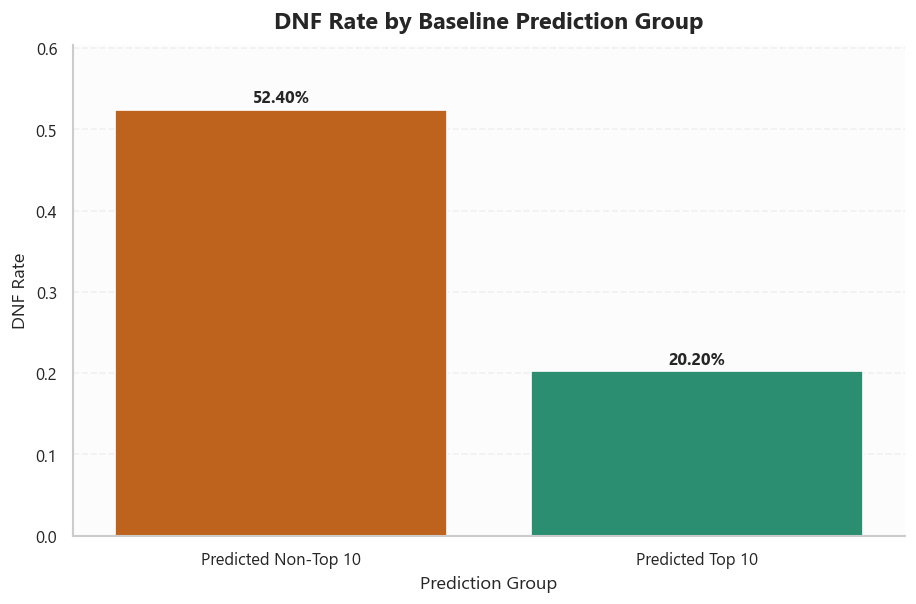

Trap check summary (survivorship bias):
Accuracy on all entries      : 76.23%
Accuracy on finishers only   : 78.05%
Difference (finishers - all) : +1.81%

DNF rate by prediction group:
     PredictionGroup  DNFRate
Predicted Non-Top 10 0.524024
    Predicted Top 10 0.202020


In [56]:
# Point 3.5: Trap awareness check (survivorship bias)
from sklearn.metrics import accuracy_score

eval_all = df.copy()
eval_finishers = df[df["DNF"] == False].copy()

acc_all = accuracy_score(eval_all["Top10"], eval_all["BaselinePred"] )
acc_finishers = accuracy_score(eval_finishers["Top10"], eval_finishers["BaselinePred"])
acc_delta = acc_finishers - acc_all

eval_scope = pd.DataFrame({
    "EvaluationScope": ["All race entries", "Finishers only"],
    "Accuracy": [acc_all, acc_finishers],
})

fig, ax = plt.subplots(figsize=(7.6, 5.2))
sns.barplot(
    data=eval_scope,
    x="EvaluationScope",
    y="Accuracy",
    hue="EvaluationScope",
    dodge=False,
    legend=False,
    palette={"All race entries": "#6c757d", "Finishers only": "#1b9e77"},
    ax=ax,
 )

for i, row in eval_scope.iterrows():
    ax.text(
        i,
        row["Accuracy"] + 0.005,
        f"{row['Accuracy']:.2%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

finalize_plot("Survivorship Bias Check: Baseline Accuracy", "Evaluation Scope", "Accuracy")
ax.set_ylim(0, min(1.0, max(eval_scope["Accuracy"]) + 0.08))
sns.despine()

plt.show()

dnf_by_pred = (
    df.groupby("BaselinePred")["DNF"]
    .mean()
    .rename(index={0: "Predicted Non-Top 10", 1: "Predicted Top 10"})
    .rename_axis("PredictionGroup")
    .reset_index(name="DNFRate")
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
sns.barplot(
    data=dnf_by_pred,
    x="PredictionGroup",
    y="DNFRate",
    hue="PredictionGroup",
    dodge=False,
    legend=False,
    palette={"Predicted Non-Top 10": "#d95f02", "Predicted Top 10": "#1b9e77"},
    ax=ax,
 )

for i, row in dnf_by_pred.iterrows():
    ax.text(
        i,
        row["DNFRate"] + 0.004,
        f"{row['DNFRate']:.2%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

finalize_plot("DNF Rate by Baseline Prediction Group", "Prediction Group", "DNF Rate")
ax.set_ylim(0, min(1.0, max(dnf_by_pred["DNFRate"]) + 0.08))
sns.despine()

plt.show()

print("Trap check summary (survivorship bias):")
print(f"Accuracy on all entries      : {acc_all:.2%}")
print(f"Accuracy on finishers only   : {acc_finishers:.2%}")
print(f"Difference (finishers - all) : {acc_delta:+.2%}")
print("\nDNF rate by prediction group:")
print(dnf_by_pred.to_string(index=False))

### Interpretation (3.5 Trap Awareness)
This is an explicit survivorship-bias check: if we evaluate only finishers, we exclude DNFs and can overstate model quality. Comparing accuracy on all entries vs finishers-only quantifies the inflation risk directly.

The second plot shows whether DNF rates differ by prediction group. If one group has much higher DNF rates, filtering out DNFs distorts class behavior and can create misleading confidence in the heuristic.

### Decision (3.5)
Use all race entries for primary evaluation and report DNF-aware diagnostics alongside accuracy. Do not present finishers-only metrics as the headline result unless clearly labeled as a sensitivity analysis.

## 3.6 Explicit temporal train/val/test split
□ eda.ipynb — Temporal split with written rationale (no random split)


Temporal split summary:
            Records  Top10Rate  Top10RatePct
DataSplit                                   
Train           440       0.50         50.00
Validation      440       0.50         50.00
Test            479       0.50         50.10


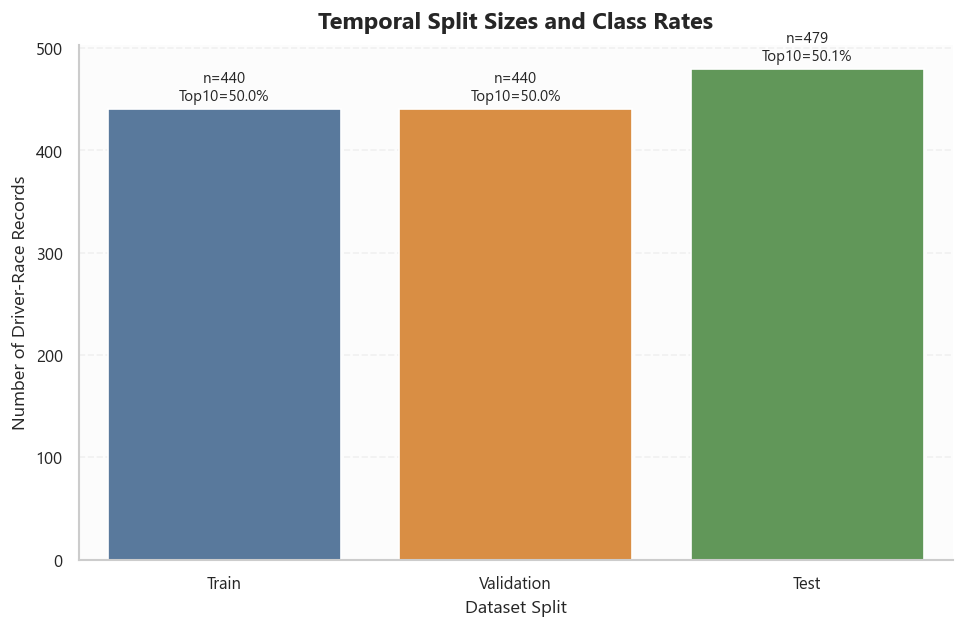

In [57]:
# Point 3.6: Temporal train/validation/test split
split_map = {2022: "Train", 2023: "Validation", 2024: "Test"}
df_split = df.copy()
df_split["DataSplit"] = df_split["Year"].map(split_map)

if df_split["DataSplit"].isna().any():
    missing_years = sorted(df_split.loc[df_split["DataSplit"].isna(), "Year"].unique().tolist())
    raise ValueError(f"Found years without split assignment: {missing_years}")

split_counts = (
    df_split.groupby("DataSplit")
    .size()
    .reindex(["Train", "Validation", "Test"])
)
split_target = (
    df_split.groupby("DataSplit")["Top10"]
    .mean()
    .reindex(["Train", "Validation", "Test"])
)

split_summary = pd.DataFrame({
    "Records": split_counts,
    "Top10Rate": split_target,
})
split_summary["Top10RatePct"] = split_summary["Top10Rate"] * 100

print("Temporal split summary:")
print(split_summary.to_string(float_format=lambda x: f"{x:.2f}"))

split_plot_df = split_summary.reset_index().rename(columns={"DataSplit": "Split"})

fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.barplot(
    data=split_plot_df,
    x="Split",
    y="Records",
    hue="Split",
    palette={"Train": "#4e79a7", "Validation": "#f28e2b", "Test": "#59a14f"},
    dodge=False,
    legend=False,
    ax=ax,
 )

for i, row in split_plot_df.iterrows():
    ax.text(
        i,
        row["Records"] + max(1, split_summary["Records"].max() * 0.01),
        f"n={int(row['Records'])}\nTop10={row['Top10RatePct']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

finalize_plot("Temporal Split Sizes and Class Rates", "Dataset Split", "Number of Driver-Race Records")
sns.despine()

plt.show()

### Rationale (3.6)
This split is strictly temporal to avoid leakage from future races into model development. Training on 2022, validating on 2023, and testing on 2024 mirrors the real forecasting setting where only past seasons are available at prediction time.

Random splitting would mix seasons and overestimate performance because race contexts and feature distributions drift over time.

## 3.7 Data quality audit
□ eda.ipynb — Missing values (MCAR/MAR/MNAR for at least 3 columns), data types, outliers, temporal availability


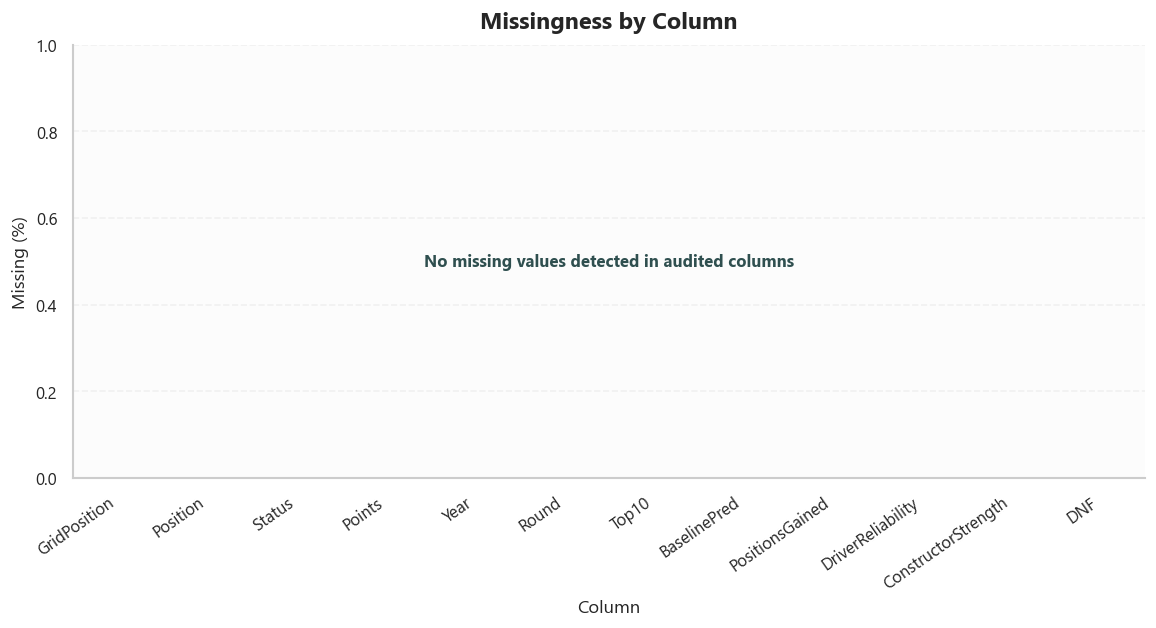

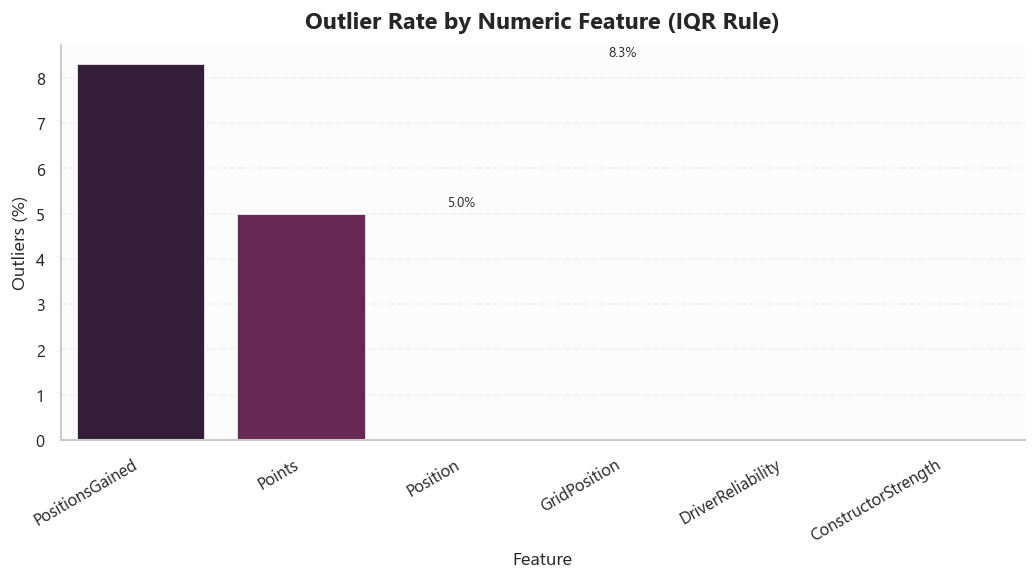

Data quality audit summary

Missingness profile:
                     MissingCount  MissingPct
GridPosition                    0         0.0
Position                        0         0.0
Status                          0         0.0
Points                          0         0.0
Year                            0         0.0
Round                           0         0.0
Top10                           0         0.0
BaselinePred                    0         0.0
PositionsGained                 0         0.0
DriverReliability               0         0.0
ConstructorStrength             0         0.0
DNF                             0         0.0

MCAR/MAR/MNAR assessment (3 required columns):
      Column  ObservedMissingPct Classification                                                                                                                      Reason
GridPosition                 0.0    Likely MNAR          If missing in raw data, usually tied to event context (e.g., no valid qualif

In [58]:
# Point 3.7: Data quality audit
audit_cols = [
    "GridPosition", "Position", "Status", "Points", "Year", "Round",
    "Top10", "BaselinePred", "PositionsGained", "DriverReliability", "ConstructorStrength", "DNF"
]

# 1) Missing values profile
missing_profile = pd.DataFrame({
    "MissingCount": df[audit_cols].isna().sum(),
    "MissingPct": (df[audit_cols].isna().mean() * 100).round(2),
}).sort_values("MissingPct", ascending=False)

fig, ax = plt.subplots(figsize=(9.8, 5.4))
missing_plot_df = missing_profile.reset_index().rename(columns={"index": "Column"})
sns.barplot(
    data=missing_plot_df,
    x="Column",
    y="MissingPct",
    hue="Column",
    dodge=False,
    legend=False,
    palette="Blues",
    ax=ax,
)
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")

max_missing = float(missing_plot_df["MissingPct"].max())
if max_missing == 0:
    ax.set_ylim(0, 1)
    ax.text(
        0.5,
        0.5,
        "No missing values detected in audited columns",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#2f4f4f",
    )
else:
    for i, row in missing_plot_df.iterrows():
        if row["MissingPct"] > 0:
            ax.text(i, row["MissingPct"] + 0.15, f"{row['MissingPct']:.1f}%", ha="center", va="bottom", fontsize=8)

finalize_plot("Missingness by Column", "Column", "Missing (%)")
sns.despine()

plt.show()

# 2) MCAR/MAR/MNAR assessment for at least 3 columns
missing_assessment = pd.DataFrame([
    {
        "Column": "GridPosition",
        "ObservedMissingPct": float(missing_profile.loc["GridPosition", "MissingPct"]),
        "Classification": "Likely MNAR",
        "Reason": "If missing in raw data, usually tied to event context (e.g., no valid qualifying/starting assignment), not random.",
    },
    {
        "Column": "Position",
        "ObservedMissingPct": float(missing_profile.loc["Position", "MissingPct"]),
        "Classification": "Likely MNAR",
        "Reason": "Missing finish position is typically race-outcome related (retirements/disqualifications), so not random.",
    },
    {
        "Column": "Status",
        "ObservedMissingPct": float(missing_profile.loc["Status", "MissingPct"]),
        "Classification": "Likely MAR",
        "Reason": "Status availability can depend on feed/event completeness; conditionally missing by source/event rather than purely random.",
    },
])

# 3) Data types audit
dtype_profile = pd.DataFrame({
    "Column": df[audit_cols].columns,
    "DType": [str(df[c].dtype) for c in audit_cols],
})

# 4) Outlier audit using IQR for numeric features
numeric_audit_cols = ["GridPosition", "Position", "Points", "PositionsGained", "DriverReliability", "ConstructorStrength"]
outlier_rows = []
for col in numeric_audit_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_count = int(((s < lower) | (s > upper)).sum())
    out_pct = (out_count / len(s) * 100) if len(s) else 0.0
    outlier_rows.append({
        "Feature": col,
        "LowerBound": lower,
        "UpperBound": upper,
        "OutlierCount": out_count,
        "OutlierPct": out_pct,
    })
outlier_df = pd.DataFrame(outlier_rows).sort_values("OutlierPct", ascending=False)

fig, ax = plt.subplots(figsize=(8.8, 5.0))
outlier_plot_df = outlier_df.copy()
sns.barplot(
    data=outlier_plot_df,
    x="Feature",
    y="OutlierPct",
    hue="Feature",
    dodge=False,
    legend=False,
    palette="rocket",
    ax=ax,
)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")
for i, row in outlier_plot_df.iterrows():
    if row["OutlierPct"] > 0:
        ax.text(i, row["OutlierPct"] + 0.1, f"{row['OutlierPct']:.1f}%", ha="center", va="bottom", fontsize=8)
finalize_plot("Outlier Rate by Numeric Feature (IQR Rule)", "Feature", "Outliers (%)")
sns.despine()

plt.show()

# 5) Temporal availability audit (pre-race vs post-race)
availability_df = pd.DataFrame([
    {"Feature": "GridPosition", "Availability": "Pre-race", "UseForPrediction": "Yes"},
    {"Feature": "Year", "Availability": "Pre-race", "UseForPrediction": "Yes"},
    {"Feature": "Round", "Availability": "Pre-race", "UseForPrediction": "Yes"},
    {"Feature": "DriverReliability", "Availability": "Pre-race (from past races)", "UseForPrediction": "Yes"},
    {"Feature": "ConstructorStrength", "Availability": "Pre-race (from past races)", "UseForPrediction": "Yes"},
    {"Feature": "Position", "Availability": "Post-race", "UseForPrediction": "No"},
    {"Feature": "Points", "Availability": "Post-race", "UseForPrediction": "No"},
    {"Feature": "Top10", "Availability": "Post-race target", "UseForPrediction": "No"},
    {"Feature": "DNF", "Availability": "Post-race", "UseForPrediction": "No"},
    {"Feature": "PositionsGained", "Availability": "Post-race", "UseForPrediction": "No"},
])

print("Data quality audit summary")
print("\nMissingness profile:")
print(missing_profile.to_string())
print("\nMCAR/MAR/MNAR assessment (3 required columns):")
print(missing_assessment.to_string(index=False))
print("\nDtype profile:")
print(dtype_profile.to_string(index=False))
print("\nOutlier profile (IQR):")
print(outlier_df[["Feature", "OutlierCount", "OutlierPct"]].to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("\nTemporal availability (pre-race vs post-race):")
print(availability_df.to_string(index=False))

### Interpretation (3.7)
The audit covers four quality dimensions required for modeling reliability: missingness behavior, data types, outlier prevalence, and temporal feature availability. The MCAR/MAR/MNAR classification highlights that not all potential missingness mechanisms are random, which affects how imputation and evaluation should be done.

Outlier rates identify where robust methods or caps may be needed, and the availability table prevents leakage by separating pre-race features from post-race variables.

### Decision (3.7)
Use only pre-race available features for predictive modeling, treat likely MNAR fields cautiously, and keep outlier-aware preprocessing for features with higher IQR outlier rates. Keep this audit as a gate before training any final model.

## 3.8 1-3-1 Summary
□ eda.ipynb — 1-3-1 summary in final Markdown cell

### 1-3-1 Summary
**1 Key Insight**
A simple grid-based Top 10 baseline is useful as a benchmark, but it is not reliable enough on its own because context (season drift, reliability, and race outcomes like DNFs) materially changes performance.

**3 Supporting Findings**
1. Baseline accuracy is moderate (~76%), with both false positives and false negatives, so grid position alone is insufficient.
2. Temporal analysis shows why random splits are inappropriate; season context must be respected, so evaluation should remain strictly time-ordered (2022 train, 2023 validation, 2024 test).
3. The survivorship-bias check showed metric inflation when filtering to finishers only (+1.81% accuracy), confirming that DNF-aware evaluation is necessary.

**1 Final Decision**
Proceed with a temporally validated, leakage-safe baseline that uses only pre-race available features (e.g., grid, historical reliability, constructor strength), and report class-aware plus DNF-aware metrics instead of accuracy alone.